# Logistic Regression

This notebook demonstrates binary logistic regression using
`rice_ml.Supervised_Learning.LogisticRegression`, which is trained with the
`GradientDescent` helper.

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure local package imports work when the notebook runs from any folder.
repo_root = Path.cwd()
while not (repo_root / "src").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
src_path = repo_root / "src"
if not src_path.exists():
    raise FileNotFoundError(f"Could not find src directory from {Path.cwd()}")
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from rice_ml.Supervised_Learning.logistic_regression_class import LogisticRegression
from rice_ml.processing.preprocessing import train_test_split, standardize
from rice_ml.processing.postprocessing import PostProcessor

from mlxtend.plotting import plot_decision_regions

# Set the Seaborn theme
sns.set_theme()

In [2]:
# Apply a simple linearly-separable binary dataset
rng = np.random.default_rng(7)
X0 = rng.normal(loc=(-1.5, -1.0), scale=0.7, size=(100, 2))
X1 = rng.normal(loc=(1.5, 1.0), scale=0.7, size=(100, 2))
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(X0.shape[0]), np.ones(X1.shape[0])])

print(X.shape, y.shape)

(200, 2) (200,)


# Preprocessing

In [3]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale the features using standardization
X_train_scaled, X_test_scaled = standardize(X_train, X_test)

# Verification
print(f"\nTraining Set Size: {X_train_scaled.shape[0]} samples")
print(f"Test Set Size: {X_test_scaled.shape[0]} samples")
print("Standardization applied using training data only.")


Training Set Size: 160 samples
Test Set Size: 40 samples
Standardization applied using training data only.


# Prediction and Evaluation

In [9]:
processor = PostProcessor()
# Instantiate and train logistic regression
model = LogisticRegression(eta=0.15, epochs=500, random_state=7)
model.train(X_train_scaled, y_train)
# Evaluate the model on the test set
y_hat = model.predict(X_test_scaled)
prob = model.predict_proba(X_test_scaled)
net = model.net_input(X_test_scaled)
acc = processor.accuracy(y_test, y_hat)
# Display results
print(f"Predicted probabilities:\n{prob[:5]}")
print(f"Test accuracy: {acc:.3f}")
print(f"Initial loss: {model.loss_history_[0]:.4f}")
print(f"Final loss:   {model.loss_history_[-1]:.4f}")
print(f"Full Classification Summary:\n{processor.classification_metrics(y_test, y_hat, labels=np.array([0, 1]))}")


Predicted probabilities:
[0.9991146  0.03010954 0.99054793 0.0344323  0.00450724]
Test accuracy: 1.000
Initial loss: 0.6918
Final loss:   0.0290
Full Classification Summary:
{'classification_error': 0.0, 'precision': 1.0, 'confusion_matrix': array([[17,  0],
       [ 0, 23]])}


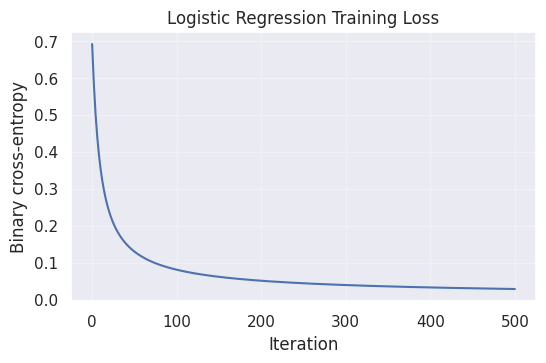

Text(0, 0.5, 'Feature 2 (standardized)')

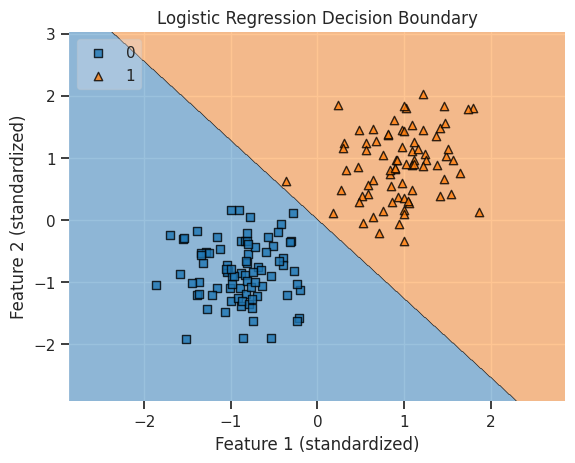

In [13]:
# Plot training loss
plt.figure(figsize=(6, 3.5))
plt.plot(model.loss_history_)
plt.title("Logistic Regression Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.grid(True, alpha=0.3)
plt.show()
# Plot the data and decision boundary
plot_decision_regions(X_train_scaled, y_train.astype(int), clf=model, legend=2)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1 (standardized)")
plt.ylabel("Feature 2 (standardized)")